# K-Means Clustering with PCA Notebook

### In the previous branch and notebooks, two algorithms performed better than the rest: **K-Means** and **GMM**.now I want test them in conjunction with dimensionality reduction algoritm **PCA**.

### I will test the **K-Means** in this notebook and **GMM** in next notebook.

#### Importing needed packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys

#### loading dataset

In [2]:
sys.path.append('..')
from src.data import load_data
df = load_data('../data/cleaned_log_data.csv')
df.head()

,Unnamed: 0,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0,2,3,9.446992,9.175438,8.930891,5.370638,7.891705,7.199678
1,1,2,3,8.861917,9.191259,9.166284,7.474772,8.099858,7.482682
2,2,2,3,8.756840,9.083529,8.947026,7.785721,8.165364,8.967632
3,3,1,3,9.492960,7.087574,8.348064,8.764834,6.230481,7.489412
4,4,2,3,10.026413,8.596189,8.881697,8.272826,7.483244,8.553718


In [3]:
df.shape

(395, 9)

#### Transform data to numpy nd array

In [4]:
features = ['Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen']

X_data = np.asanyarray(df[features])
X_data

array([[ 9.44699227,  9.17543832,  8.93089098,  5.37063803,  7.89170466,
         7.19967835],
       [ 8.861917  ,  9.19125948,  9.16628399,  7.47477218,  8.09985791,
         7.48268183],
       [ 8.75683981,  9.08352921,  8.94702566,  7.7857209 ,  8.16536363,
         8.96763167],
       ...,
       [10.57717155,  7.26682735,  6.63987583,  8.41427414,  4.54329478,
         7.7608932 ],
       [ 9.58410839,  9.64788537, 10.3170531 ,  6.08221891,  9.60521628,
         7.53262362],
       [ 9.23902501,  7.59186171,  7.71110125,  6.94601399,  5.12989871,
         7.66199756]], shape=(395, 6))

#### Dimention reduce using PCA

PC0 : 2.69 (44.70%)
PC1 : 1.54 (25.53%)
PC2 : 0.70 (11.57%)
PC3 : 0.63 (10.51%)
PC4 : 0.30 (4.92%)
PC5 : 0.17 (2.77%)


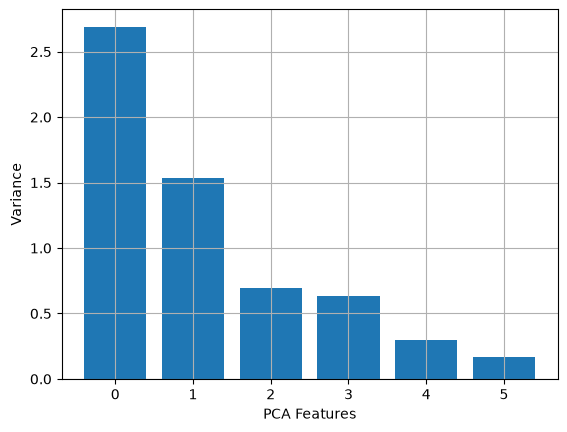

In [5]:
from src.pca import pca_maker
pca, pca_labels = pca_maker(X_data)

### According to variencec values, I will test PC0 to PC3 thats about 92% of data

#### Drow a plot to visualize data (2 features)

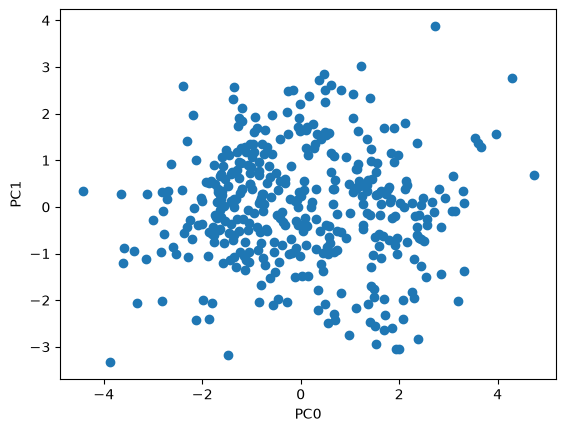

In [6]:
plt.scatter(pca_labels[:,0], pca_labels[:,1])
plt.xlabel('PC0')
plt.ylabel('PC1')
plt.show()

#### Training model

In [7]:
X_pca = pca_labels[:,:1]
X_pca.shape

(395, 1)

K : 2, Score : 0.60451094795724
K : 3, Score : 0.5472173448028876
K : 4, Score : 0.5431411524540509
K : 5, Score : 0.5567068815755865
K : 6, Score : 0.5426743258631375
K : 7, Score : 0.5372376316173062
K : 8, Score : 0.5387983688166188
K : 9, Score : 0.5444308969098073
K : 10, Score : 0.5426226405142734
K : 11, Score : 0.5454664928451274
K : 12, Score : 0.5445932254260353
K : 13, Score : 0.5472972468588706
K : 14, Score : 0.552032409531611
K : 15, Score : 0.5534971932406816
K : 16, Score : 0.554283774405804
K : 17, Score : 0.5509287670372585
K : 18, Score : 0.5435335800548479
K : 19, Score : 0.5298299735004399
K : 20, Score : 0.5376880334153654
K : 21, Score : 0.5499271631085304
K : 22, Score : 0.5281253465244531
K : 23, Score : 0.537787959804616
K : 24, Score : 0.5443408575622941
K : 25, Score : 0.5467034537229494
K : 26, Score : 0.5469712060598502
K : 27, Score : 0.5454370505799032
K : 28, Score : 0.5483543865292149
K : 29, Score : 0.5508468016924954
K : 30, Score : 0.547330743034404

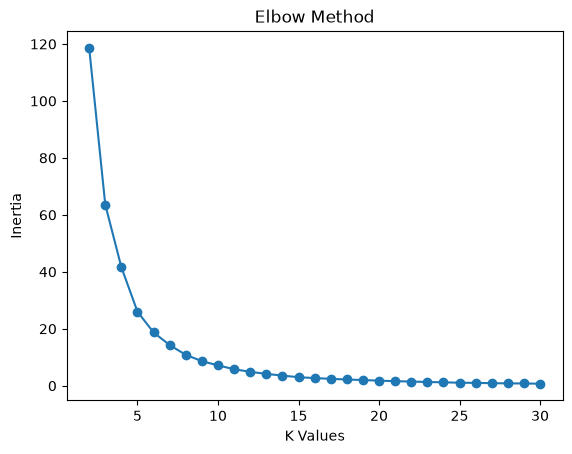

In [8]:
from src.clustering import kmeans_pipeline
model = kmeans_pipeline(X_pca)
labels = model.predict(X_pca)

In [9]:
print(np.bincount(labels))

[172 223]


In [10]:
df_exp = df
df_exp['labels'] = labels
cluster_profile = df_exp.groupby('labels')[features].mean()

print(cluster_profile)

           Fresh      Milk   Grocery    Frozen  Detergents_Paper  Delicassen
labels                                                                      
0       8.747856  8.947554  9.308389  7.167912          8.167940    7.178831
1       9.069716  7.478668  7.721082  7.629691          5.720864    6.526907


In [11]:
pc0_loadings = pd.Series(pca.components_[0], index=features).sort_values(ascending=False)
print(pc0_loadings)

Grocery             0.570740
Milk                0.546273
Detergents_Paper    0.534483
Delicassen          0.265838
Fresh              -0.085209
Frozen             -0.110629
dtype: float64


#### PCA did not consistently improve clustering quality. Interestingly, clustering on the first principal component alone produced a substantially higher silhouette score, suggesting that a dominant purchasing pattern captured by PC0 provides strong one-dimensional separation, while incorporating additional components introduces other sources of variation that reduce cluster compactness/separation under the silhouette criterion.

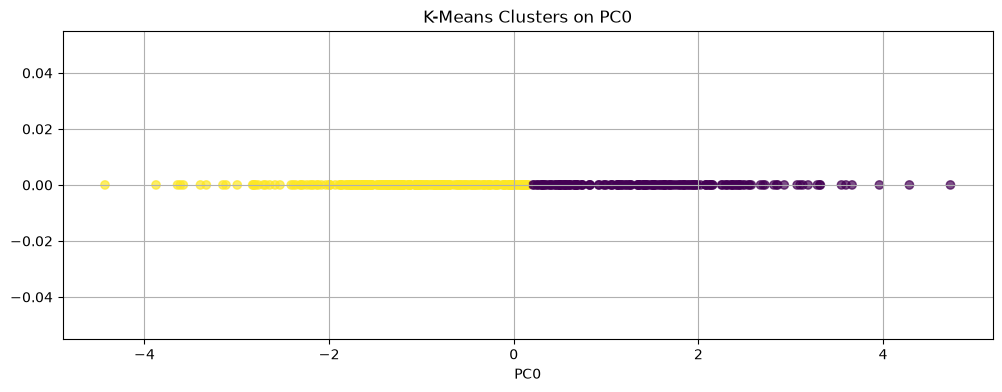

In [12]:
plt.figure(figsize=(12, 4))

plt.scatter(X_pca[:, 0], np.zeros_like(X_pca[:, 0]), c=labels, alpha=0.7)

plt.xlabel("PC0")
plt.title("K-Means Clusters on PC0")
plt.grid()
plt.show()

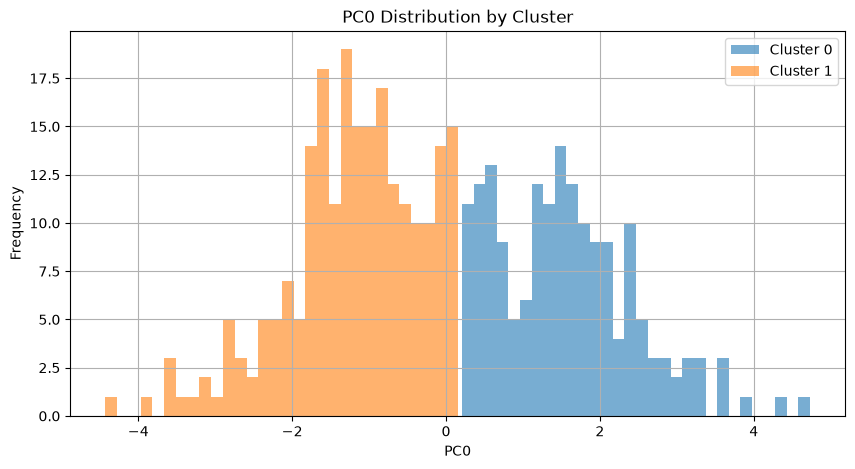

In [16]:
plt.figure(figsize=(10, 5))

plt.hist(X_pca[labels == 0, 0], bins=30, alpha=0.6, label="Cluster 0")
plt.hist(X_pca[labels == 1, 0], bins=30, alpha=0.6, label="Cluster 1")

plt.xlabel("PC0")
plt.ylabel("Frequency")
plt.title("PC0 Distribution by Cluster")
plt.legend()
plt.grid()

plt.show()

In [17]:
for cluster in [0, 1]:
    values = X_pca[labels == cluster, 0]
    print(
        f"Cluster {cluster}: "
        f"mean={values.mean():.3f}, "
        f"median={np.median(values):.3f}, "
        f"min={values.min():.3f}, "
        f"max={values.max():.3f}"
    )

Cluster 0: mean=1.560, median=1.495, min=0.208, max=4.730
Cluster 1: mean=-1.203, median=-1.139, min=-4.428, max=0.158


In [18]:
from sklearn.metrics import silhouette_samples

sil = silhouette_samples(X_pca[:, :1], labels)

print("Cluster 0:", sil[labels == 0].mean())
print("Cluster 1:", sil[labels == 1].mean())

Cluster 0: 0.597957441893242
Cluster 1: 0.6095656701231933


#### Using only the first principal component substantially increased the silhouette score, whereas adding subsequent components progressively reduced it.

#### This suggests that the dominant structure captured by PC0 is particularly relevant to the two-cluster segmentation, while the additional principal components introduce variation that does not improve separation according to the silhouette criterion.

#### K-Means with K=2 on the first principal component (PC0) provides the strongest and highly stable clustering structure identified in this dataset, achieving a Silhouette Score of approximately 0.6045.

#### Interpretation

In [19]:
df_exp = df.copy()
df_exp['labels'] = labels

In [20]:
cluster_profile = (df_exp.groupby('labels')[features].agg(['mean', 'median']))
cluster_profile

Fresh                Milk             Grocery              Frozen  \
            mean    median      mean    median      mean    median      mean   
labels                                                                         
0       8.747856  8.883070  8.947554  8.885577  9.308389  9.282467  7.167912   
1       9.069716  9.189219  7.478668  7.528869  7.721082  7.732369  7.629691   

                 Detergents_Paper           Delicassen            
          median             mean    median       mean    median  
labels                                                            
0       7.154997         8.167940  8.315196   7.178831  7.345360  
1       7.695758         5.720864  5.752573   6.526907  6.590301

#### Count od custommers in cluster

In [21]:
cluster_size = df_exp['labels'].value_counts().sort_index()
cluster_size

labels
0    172
1    223
Name: count, dtype: int64

#### Percentage of cluster labels relative to the Region

In [22]:
pd.crosstab(df_exp['labels'], df_exp['Region'], normalize= 'index')

Region,1,2,3
labels,,,
0,0.168605,0.093023,0.738372
1,0.197309,0.121076,0.681614


#### Percentage of cluster labels relative to the Channels

In [23]:
pd.crosstab(df_exp['labels'], df_exp['Channel'], normalize="index")

Channel,1,2
labels,,
0,0.325581,0.674419
1,0.973094,0.026906


#### Cluster profile with Z-Score, it shows the different between cluster mean and overal mean for any features

In [24]:
df_Z = pd.DataFrame(index=sorted(df_exp['labels'].unique()))

for feature in features:
    cluster_mean = df_exp.groupby('labels')[feature].mean()
    overall_mean = df_exp[feature].mean()
    overall_std = df_exp[feature].std()
    
    df_Z[feature] = (cluster_mean - overall_mean) / overall_std

df_Z

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,-0.162525,0.830176,0.886953,-0.232203,0.861442,0.368389
1,0.125356,-0.640315,-0.684107,0.179098,-0.664431,-0.284138


#### Shwoing the pattern using heatmap

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

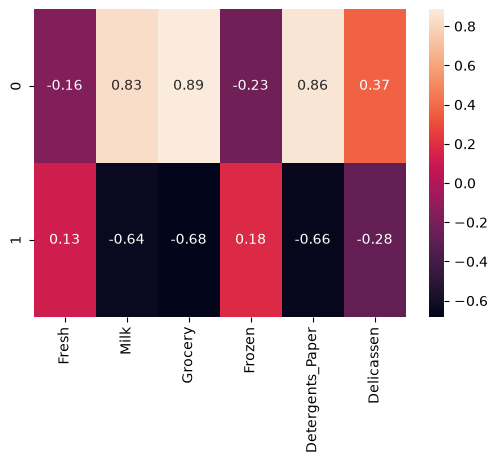

In [26]:
plt.figure(figsize= (6 , 4))

sns.heatmap(data= df_Z, annot= True, fmt= '.2f')

plt.show()

## Conclusion

After evaluating K-Means with different numbers of clusters and different combinations of **Principal Components**, a clear two-cluster structure was identified when using the **first principal component (PC0)** alone. The best result was obtained with **K = 2**, achieving a **Silhouette Score of 0.6045**.

This result is substantially higher than the best score obtained on the original standardized six-dimensional feature space, where **K = 2** achieved a Silhouette Score of approximately **0.2898**. Interestingly, adding subsequent principal components did not improve the clustering quality. Instead, the Silhouette Score progressively decreased as additional components were included. This suggests that the dominant structure relevant to the two-cluster segmentation is primarily captured by **PC0**, while the additional components introduce variation that does not improve cluster separation according to the Silhouette criterion.

The stability of this solution was also evaluated using different `random_state` values. The resulting cluster assignments and Silhouette Score remained unchanged, indicating that the identified two-cluster solution is highly stable with respect to K-Means initialization.

The two clusters contain **172** and **223** customers, respectively, resulting in a relatively balanced segmentation rather than a clustering dominated by a small outlier group.

An examination of the **PC0 loadings** shows that this component is primarily associated with `Grocery`, `Milk`, and `Detergents_Paper`, with weaker contributions from `Delicassen`, `Fresh`, and `Frozen`. Therefore, PC0 can be interpreted as a dominant **purchasing-pattern axis**, distinguishing customers according to their relative purchasing behavior across these product categories.

The cluster distributions along PC0 further support this interpretation. Cluster 0 has PC0 values ranging from approximately `0.208` to `4.730`, while Cluster 1 ranges from approximately `-4.428` to `0.158`. The two groups therefore exhibit a small gap between their observed ranges, with no overlap in the PC0 values. Furthermore, the mean silhouette values of the two clusters are highly similar (`0.598` for Cluster 0 and `0.610` for Cluster 1), indicating that the observed separation is not driven by only one of the clusters.

The cluster profiles in the original feature space also reveal a clear difference in purchasing patterns:

| Cluster |    Fresh |     Milk |  Grocery |   Frozen | Detergents_Paper | Delicassen |
| ------- | -------: | -------: | -------: | -------: | ---------------: | ---------: |
| 0       | 8.747856 | 8.947554 | 9.308389 | 7.167912 |         8.167940 |   7.178831 |
| 1       | 9.069716 | 7.478668 | 7.721082 | 7.629691 |         5.720864 |   6.526907 |

Cluster 0 is characterized by substantially higher purchases of **Milk, Grocery, and Detergents_Paper**, while Cluster 1 shows relatively higher purchases of **Fresh** and **Frozen** products. The difference in `Fresh` and `Frozen` is comparatively smaller than the differences observed in `Milk`, `Grocery`, and `Detergents_Paper`.

Overall, the analysis indicates that the Wholesale Customers dataset contains a **stable two-cluster structure**, with the strongest separation captured by the first principal component. Therefore, **K-Means with K = 2 using PC0** is selected as the final clustering configuration for this analysis.

Further analysis can focus on interpreting these two customer segments from a business perspective and examining how their purchasing behavior differs across product categories, regions, and channels.
